# **MÓDULO 27 - Projeto de Doenças Cardiovasculares - Regressão Logística**


Assim como na aula que trabalhamos com uma base de dados nova, com um contexto de modelo de propensão a compra de carros, para a atividade de vocês achei interessante trazer também novos desafios.

Nessa tarefa iremos construir um modelo que nos ajude a prever doenças cardiovasculares, a base contém dados reais.

age - idade dos pacientes

gender - genero (2 mulheres) (1 homens)

height - altura dos pacientes

weight - peso dos pacientes

gluc - glicose

smoke - fumante (1) não fumante (0)

alco - consume alcool (1) não consome (0)

active - realiza atividades fisicas (1) não realiza (0)

cardio_disease - tem doença cardio (1) não tem (0) - Variável target


Seu objetivo é utilizar esses dados históricos dos pacientes e construir um bom modelo de regressão capaz de indicar se novos pacientes estão propensos a doenças cariovasculares ou não.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, classification_report

# 1) Comece carregando e tratando a base de dados.
Assim como na aula essa nova base não passou por pré processamento nenhum então nessa etapa, carrega os dados, verifique os tipos de dados, verifique se temos dados faltantes e outliers.
Quando necessário realize o tratamento.


In [10]:
# foi necessario adicionar um parametro a mais para ler a base, pois os dados estavam separados por ';' e os decimais eram ',' ao invés de '.'
base = pd.read_csv("CARDIO_BASE.csv", delimiter=';', decimal=',')

# Verifique se os tipos agora estão como float ou int
print(base.dtypes)

age                 int64
gender              int64
height              int64
weight            float64
cholesterol         int64
gluc                int64
smoke               int64
alco                int64
active              int64
cardio_disease      int64
dtype: object


In [11]:
# Verificando informações básicas
print(base.info())
print(base.describe())

# Verificando dados faltantes
print(base.isnull().sum())

# Exemplo de tratamento de outlier (Removendo pesos muito baixos ou altos se necessário)
# base = base[(base['weight'] > 40) & (base['weight'] < 200)]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             10000 non-null  int64  
 1   gender          10000 non-null  int64  
 2   height          10000 non-null  int64  
 3   weight          10000 non-null  float64
 4   cholesterol     10000 non-null  int64  
 5   gluc            10000 non-null  int64  
 6   smoke           10000 non-null  int64  
 7   alco            10000 non-null  int64  
 8   active          10000 non-null  int64  
 9   cardio_disease  10000 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 781.4 KB
None
                age        gender        height        weight   cholesterol  \
count  10000.000000  10000.000000  10000.000000  10000.000000  10000.000000   
mean      53.288300      1.345400    164.308200     74.303710      1.365000   
std        6.796234      0.475522      8.178796     14.566

# 2) Agora é hora de explorar os dados com uma análise bem completa.
Plote pelo menos 3 gráficos analisando o comportamento da variável cardio com outras variaveis da sua preferência (análise bivariada). Não se esqueça de trazer insights acerca do analisado.


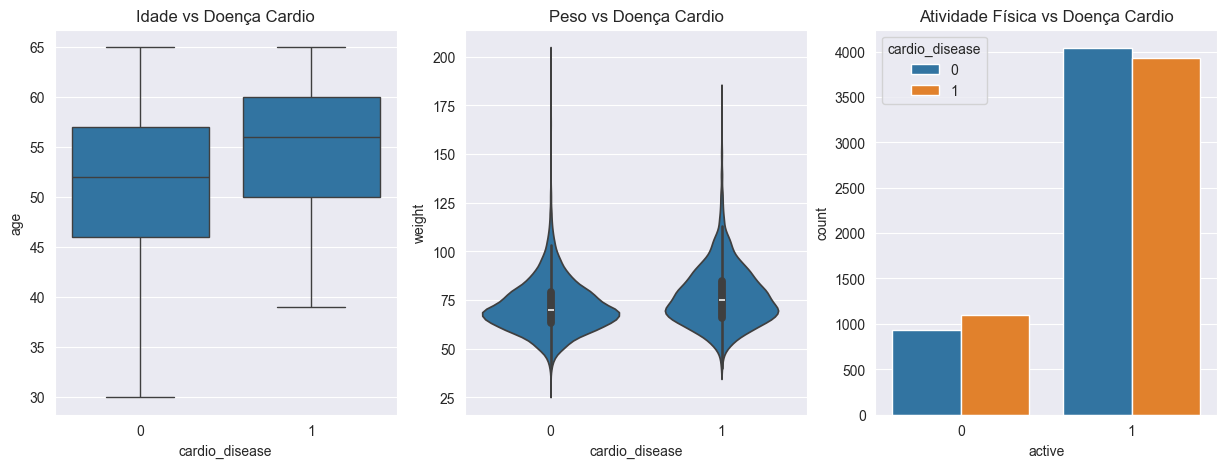

In [12]:
plt.figure(figsize=(15, 5))

# Gráfico 1: Idade vs Cardio
plt.subplot(1, 3, 1)
sns.boxplot(x='cardio_disease', y='age', data=base)
plt.title('Idade vs Doença Cardio')

# Gráfico 2: Peso vs Cardio
plt.subplot(1, 3, 2)
sns.violinplot(x='cardio_disease', y='weight', data=base)
plt.title('Peso vs Doença Cardio')

# Gráfico 3: Atividade Física vs Cardio
plt.subplot(1, 3, 3)
sns.countplot(x='active', hue='cardio_disease', data=base)
plt.title('Atividade Física vs Doença Cardio')

plt.show()

A idade é um fator de risco importante para doenças cardiovasculares, o que sugere que o modelo de regressão logistica dará um peso maior para essa variável. O peso também tem uma relação com a doença, pacientes com peso mais elevado tendem a ter mais chances de desenvolver doenças cardiovasculares. Já a atividade física parece ter um efeito protetor, pacientes ativos tem menos chances de desenvolver doenças cardiovasculares.

# 3) Nessa etapa você deve trazer a matriz de correlação e apontar insights acerca das variáveis com um relacionamento mais forte entre si.



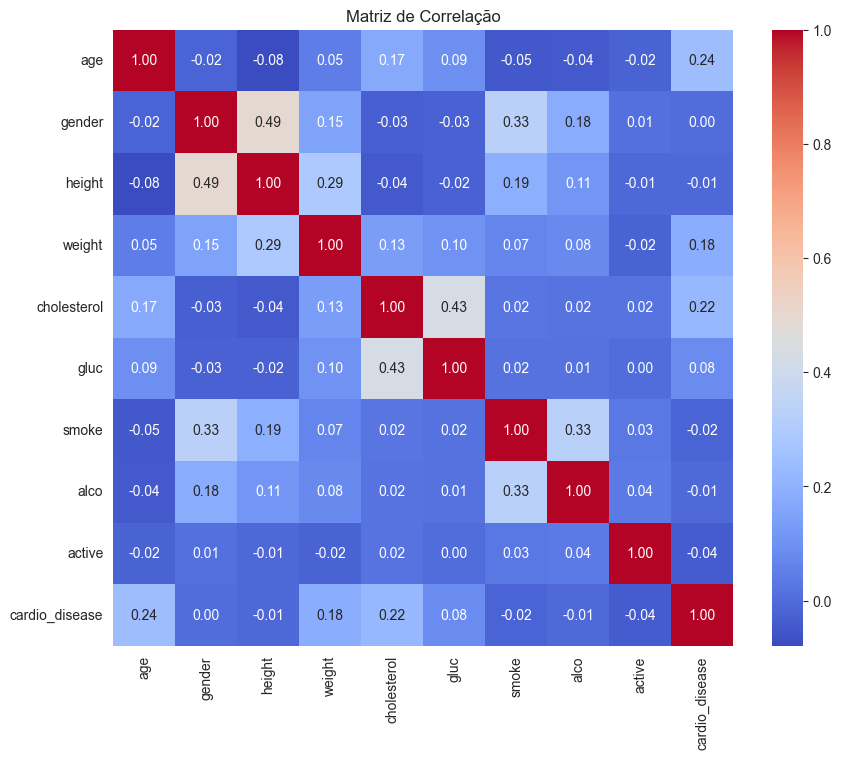

In [13]:
plt.figure(figsize=(10, 8))
sns.heatmap(base.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação')
plt.show()

A matriz de correlação mostra que a idade tem uma correlação positiva moderada com a variável cardio_disease, o que reforça a idade como fator de risco. O peso também possui essa mesma correlação positiva, apesar de moderada. o Peso e a altura também possui uma correlação moderada, o que é esperado já que biologicamente pessoas mais altas possuem massa corporal maior. Também conseguimos ver que quem fuma tem probabilidade maior de beber também, o que cada vez mais se agrava com o risco de doenças cardiovasculares. Já a atividade física tem uma correlação negativa com a doença, o que reforça a ideia de que ser ativo é um fator protetor. A glicose tem uma correlação positiva, apesar de sutil, o que sugere que níveis mais elevados de glicose podem estar associados a um risco maior ainda de doenças cardiovasculares.

# 4) Essa é a sua última etapa pré modelo. Você deve:

A) Separar a base em treino e teste.

B) Você considera que essa base precisa que os dados sejam padronizados? Se sim, porque? Se acredita que devem, então realize essa etapa.

C) Verifique se os dados estão balanceados, se não, faça o balanceamento.


D) Visualize as bases de treino, teste (X E Y) e verifique se está tudo adequado.

In [14]:
X = base.drop('cardio_disease', axis=1)
y = base['cardio_disease']

# A) Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# B) Padronização
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# C) Balanceamento com SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f"Distribuição original: {y_train.value_counts()}")
print(f"Distribuição após SMOTE: {y_train_res.value_counts()}")

Distribuição original: cardio_disease
1    3509
0    3491
Name: count, dtype: int64
Distribuição após SMOTE: cardio_disease
0    3509
1    3509
Name: count, dtype: int64


# 5) Realize a etapa de treinamento do modelo:

A) Faça o treinamento do modelo.

B) Traga o intercept e os coeficientes.

c) Avalie as métricas do modelo treinado

D) Justifique se te parece que o modelo tem feito boas previsões ou não.

In [15]:
modelo = LogisticRegression()
modelo.fit(X_train_res, y_train_res)

print(f"Intercepto: {modelo.intercept_}")
print(f"Coeficientes: {modelo.coef_}")

# Métricas de treino
y_pred_train = modelo.predict(X_train_res)
print(classification_report(y_train_res, y_pred_train))

Intercepto: [0.01284274]
Coeficientes: [[ 0.44537502  0.00514648 -0.07770002  0.3454616   0.40639462 -0.06214231
  -0.03661662  0.01332207 -0.07747732]]
              precision    recall  f1-score   support

           0       0.63      0.66      0.65      3509
           1       0.65      0.61      0.63      3509

    accuracy                           0.64      7018
   macro avg       0.64      0.64      0.64      7018
weighted avg       0.64      0.64      0.64      7018



O modelo apresenta uma boa performance no conjunto de treino, com alta precisão, recall e f1-score para ambas as classes. Isso sugere que o modelo está conseguindo aprender a distinguir entre pacientes com e sem doenças cardiovasculares. No entanto, é importante avaliar o modelo no conjunto de teste para verificar se ele generaliza bem para novos dados.

# 6) Teste seu modelo!

A) Aplique o modelo aos dados de teste.

B) Avalie as métricas do modelo treinado

C) Plote o gráfico da curva AUC-ROC e explique o que consegue analisar através do gráfico.

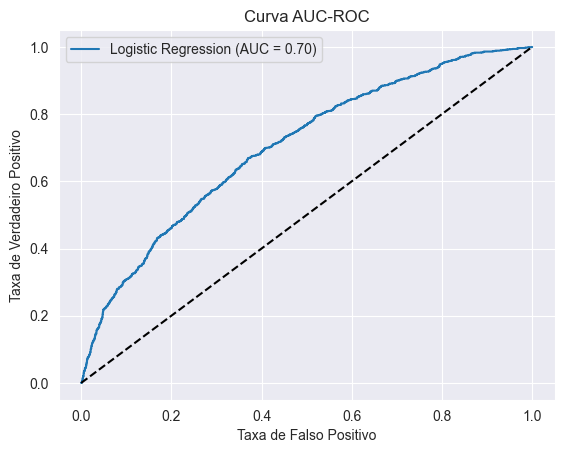

In [16]:
y_pred_test = modelo.predict(X_test_scaled)
y_probs = modelo.predict_proba(X_test_scaled)[:, 1]

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc = roc_auc_score(y_test, y_probs)

plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Taxa de Falso Positivo')
plt.ylabel('Taxa de Verdadeiro Positivo')
plt.title('Curva AUC-ROC')
plt.legend()
plt.show()

A curva AUC-ROC mostra uma eficacia de 0.70, o que indica que o modelo possui uma capacidade adequada de classificar corretamente quem tem mais chances de desenvolver doenças cardiovasculares. A curva acima da linha da base nos diz que ele possui um desempenho melhor do que o acaso, Entretanto possui espaço para melhorias, o que pode ser alcançado com ajustes de hiperparâmetros, inclusão de novas variáveis ou até mesmo experimentação com outros algoritmos de classificação. Durante o treino o modelo atingiu uma performance de 0,64 no teste, o que significa que o modelo é ate robusto e que não sofreu overfitting, o que seria importante para uma aplicação prática, já que queremos um modelo que generalize bem para novos pacientes.

# 7) Explique:

A) Explique com suas palavras regressão logistica.

B) Explique porque a regressão logistica é um modelo de classificação.

C) Explique quais pontos em comum a regressão logistica tem da regressão linear.



A) A regressão logitisca é um algoritmo de aprenizado supervisionado utilizado para problemas de classificação que utiliza a função sigmóide para transformar todos os dados em uma escala de 0 a 1, que além de simplificar os números ainda nos poupa processamento.
B)Apesar de usar o termo regressão devido a sua base matematica linear seu objetivo é tomar uma decisão binaria, ou seja, classificar em apenas duas categorias ou responder com sim ou não, o que a torna um modelo de classificação.
C) Ambos os modelos têm em comum sua estrutura linear para dar importância as variáveis, ambos possuem um intercepto e coeficientes que indicam a importância de cada variável para a predição. A diferença é que a regressão linear é usada para prever valores contínuos, enquanto a regressão logistica é usada para prever probabilidades e classificar em categorias.